# Learning on Graphs: Homework 2

## Spatio-Temporal Forecasting on Graphs

This notebook accompanies the assignment PDF. Complete the cells marked `TODO`, keep the default settings unless the PDF asks otherwise, and submit the completed notebook together with the report.


In [30]:
import math
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

# Keep numerical experiments lightweight and reproducible across machines.
torch.set_num_threads(1)


device: cuda


In [31]:
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)


## Part A: temporal graph dataset and forecasting windows

The functions below are provided. Use them to generate the dataset, visualize it, and construct chronological forecasting windows.


In [32]:
def make_sbm_graph(seed=0, sizes=(30, 30), probs=None, largest_component=True):
    if probs is None:
        probs = [[0.18, 0.02], [0.02, 0.18]]
    graph = nx.stochastic_block_model(list(sizes), probs, seed=seed)
    if largest_component and not nx.is_connected(graph):
        largest = max(nx.connected_components(graph), key=len)
        graph = graph.subgraph(largest).copy()
        graph = nx.convert_node_labels_to_integers(graph)
    return graph


def normalized_adjacency(graph):
    adjacency = nx.to_numpy_array(graph, dtype=np.float32)
    adjacency = adjacency + np.eye(adjacency.shape[0], dtype=np.float32)
    degree = adjacency.sum(axis=1)
    degree_inv_sqrt = np.power(degree, -0.5)
    degree_inv_sqrt[~np.isfinite(degree_inv_sqrt)] = 0.0
    return (degree_inv_sqrt[:, None] * adjacency * degree_inv_sqrt[None, :]).astype(np.float32)


def graph_stats(graph):
    degrees = np.array([degree for _, degree in graph.degree()], dtype=float)
    return {
        "num_nodes": graph.number_of_nodes(),
        "num_edges": graph.number_of_edges(),
        "average_degree": float(degrees.mean()),
        "max_degree": int(degrees.max()),
        "is_connected": nx.is_connected(graph),
    }


In [33]:
def make_forcing(num_nodes, total_steps, source_fraction=0.12, seed=0):
    rng = np.random.default_rng(seed)
    num_sources = max(1, int(source_fraction * num_nodes))
    source_nodes = rng.choice(num_nodes, size=num_sources, replace=False)
    forcing = np.zeros((total_steps, num_nodes), dtype=np.float32)

    time = np.arange(total_steps, dtype=np.float32)
    for node in source_nodes:
        frequency = rng.uniform(0.03, 0.08)
        phase = rng.uniform(0.0, 2.0 * np.pi)
        amplitude = rng.uniform(0.7, 1.3)
        forcing[:, node] = amplitude * np.sin(frequency * time + phase)
    return forcing, source_nodes


def simulate_temporal_signal(
    normalized_adj,
    total_steps=400,
    alpha=0.45,
    beta=0.35,
    gamma=0.15,
    noise_std=0.03,
    seed=0,
):
    rng = np.random.default_rng(seed)
    num_nodes = normalized_adj.shape[0]
    forcing, source_nodes = make_forcing(num_nodes, total_steps, seed=seed)
    signals = np.zeros((total_steps, num_nodes), dtype=np.float32)
    signals[0] = rng.normal(0.0, 0.2, size=num_nodes).astype(np.float32)

    for time_index in range(total_steps - 1):
        noise = rng.normal(0.0, noise_std, size=num_nodes).astype(np.float32)
        signals[time_index + 1] = (
            alpha * (normalized_adj @ signals[time_index])
            + beta * signals[time_index]
            + gamma * forcing[time_index]
            + noise
        )
    return signals, forcing, source_nodes


In [34]:
def plot_graph(graph, values=None, position=None, title="Graph", vmin=None, vmax=None):
    if position is None:
        position = nx.spring_layout(graph, seed=0)
    plt.figure(figsize=(5, 4))
    if values is None:
        nx.draw_networkx(
            graph,
            pos=position,
            node_size=80,
            with_labels=False,
            edge_color="0.75",
            node_color="tab:blue",
        )
    else:
        nx.draw_networkx_edges(graph, position, edge_color="0.80", width=0.8)
        nodes = nx.draw_networkx_nodes(
            graph,
            position,
            node_color=values,
            node_size=80,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax,
        )
        plt.colorbar(nodes, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.axis("off")
    plt.show()
    return position


def plot_node_series(signals, node_indices, title="Selected node signals"):
    plt.figure(figsize=(8, 3))
    for node in node_indices:
        plt.plot(signals[:, node], label=f"node {node}")
    plt.xlabel("time")
    plt.ylabel("signal value")
    plt.title(title)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(history, title="Training curves"):
    plt.figure(figsize=(5, 3))
    plt.plot(history["train"], label="train")
    plt.plot(history["val"], label="validation")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [35]:
# A1: generate the default graph and temporal signals.
# Required objects: G, A_hat, X, U, source_nodes, train_end, val_end.

set_seed(0)
T = 400
G = make_sbm_graph()
A_hat = normalized_adjacency(G)
simulate_temporal_signal
X, U, source_nodes = simulate_temporal_signal(A_hat, total_steps=T)
train_end, val_end = int(0.6 * T), int(0.8 * T)

[print(f"{k}: {v}") for k, v in graph_stats(G).items()]
print(f"train: ({0} -> {train_end-1})\nval: ({train_end} -> {val_end-1})\ntest: ({val_end} -> {T})")


num_nodes: 60
num_edges: 189
average_degree: 6.3
max_degree: 12
is_connected: True
train: (0 -> 239)
val: (240 -> 319)
test: (320 -> 400)


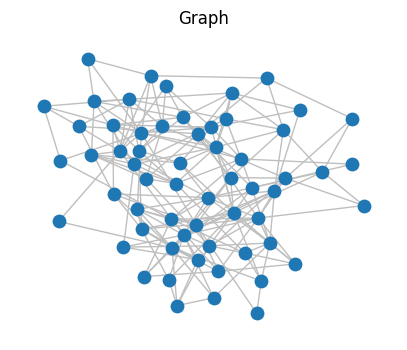

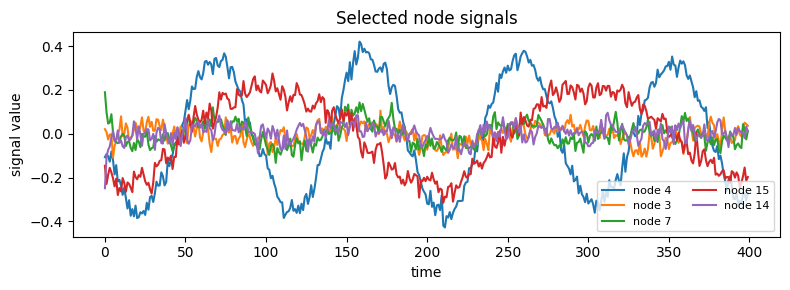

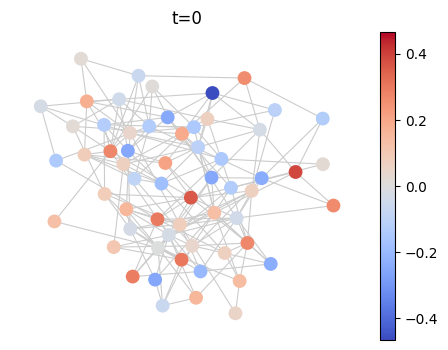

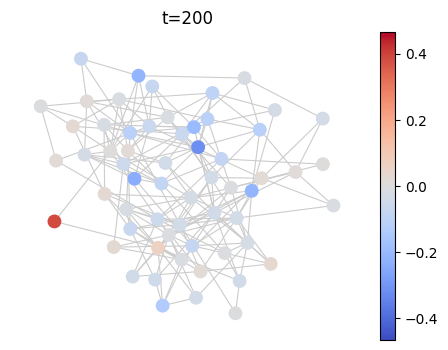

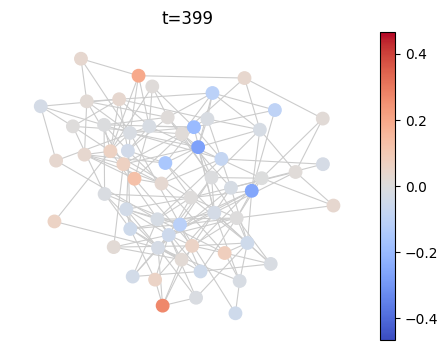

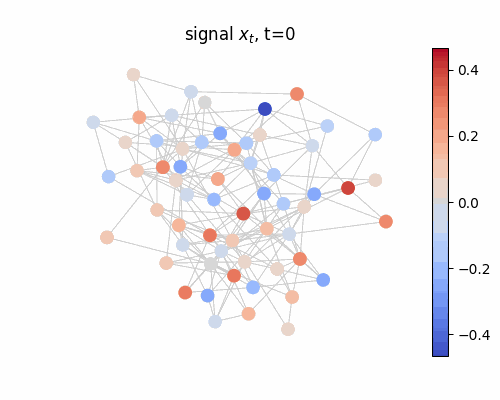

In [36]:
# A2: create the required figures:

# 1. graph visualization,
plot_graph(G)

# 2. time series for 5 selected nodes,
plot_node_series(X,[4,3,7,15,14])

# 3. graph-signal snapshots at 3 time points.
vmax = float(np.abs(X).max()); vmin = -vmax
_ = plot_graph(G, X[0, :],          vmin=vmin, vmax=vmax, title="t=0")
_ = plot_graph(G, X[int(0.5*T), :], vmin=vmin, vmax=vmax, title=f"t={int(0.5*T)}")
_ = plot_graph(G, X[T-1, :],        vmin=vmin, vmax=vmax, title=f"t={T-1}")


# A2 (extra): animated GIF built by stitching frames from the provided plot_graph
import matplotlib
import os
from PIL import Image as PILImage
from IPython.display import Image, display

os.makedirs("figures", exist_ok=True)
# reuse the same fixed layout (pos) and symmetric color range (vmin/vmax) as the snapshots above

orig_backend = matplotlib.get_backend()
plt.switch_backend("Agg")                      # render off-screen so plot_graph's show() isn't dumped inline
imgs = []
for t in range(0, T, 4):                        # subsample 400 -> 100 frames
    plot_graph(G, X[t], title=f"signal $x_t$, t={t}", vmin=vmin, vmax=vmax)
    fig = plt.gcf(); fig.canvas.draw()
    imgs.append(PILImage.fromarray(np.asarray(fig.canvas.buffer_rgba()).copy()))
    plt.close(fig)
plt.switch_backend(orig_backend)                # restore the inline backend

gif_path = "figures/A2_signal_evolution.gif"
imgs[0].save(gif_path, save_all=True, append_images=imgs[1:], duration=80, loop=0)
display(Image(filename=gif_path, embed=True))   # animates inline AND embeds into the .ipynb


In [37]:
def make_windows(signals, window_size, train_end, validation_end):
    # Construct chronological forecasting windows.
    # Returns a dictionary with keys train, val, test.
    # Each value is (inputs, targets, target_times), where
    #   inputs has shape num_examples x num_nodes x window_size,
    #   targets has shape num_examples x num_nodes.
    # The target for a window ending at time t is x_{t+1}.
    total_steps = signals.shape[0]
    buckets = {"train": ([], [], []), "val": ([], [], []), "test": ([], [], [])}

    # Sliding windows, stride 1: one example per valid target time.
    for end_time in range(window_size - 1, total_steps - 1):
        target_time = end_time + 1
        H = signals[end_time - window_size + 1 : end_time + 1].T  # (n, L)
        y = signals[target_time]                                 # (n,)

        # Assign by target_time so no future target leaks into an earlier split.
        if target_time < train_end:
            split = "train"
        elif target_time < validation_end:
            split = "val"
        else:
            split = "test"

        inputs, targets, times = buckets[split]
        inputs.append(H)
        targets.append(y)
        times.append(target_time)

    return {
        split: (
            np.asarray(inputs, dtype=np.float32),   # num_examples x n x L
            np.asarray(targets, dtype=np.float32),  # num_examples x n
            np.asarray(times, dtype=np.int64),      # num_examples
        )
        for split, (inputs, targets, times) in buckets.items()
    }


# A3: construct windows for L=5 and report split sizes.
L = 5
windows = make_windows(X, L, train_end, val_end)
for split in ("train", "val", "test"):
    inputs, targets, times = windows[split]
    rng = f"target t in [{times.min()} .. {times.max()}]" if len(times) else "empty"
    print(f"{split}: {inputs.shape[0]:>3} windows | inputs {inputs.shape} | targets {targets.shape} | {rng}")


train: 235 windows | inputs (235, 60, 5) | targets (235, 60) | target t in [5 .. 239]
val:  80 windows | inputs (80, 60, 5) | targets (80, 60) | target t in [240 .. 319]
test:  80 windows | inputs (80, 60, 5) | targets (80, 60) | target t in [320 .. 399]


## Part B: forecasting baselines

Implement the persistence baseline, a node-wise temporal MLP, and the linear diffusion baseline.


In [38]:
def mse_np(prediction, target):
    return float(np.mean((prediction - target) ** 2))


def evaluate_persistence(windows):
    # Persistence baseline: predict x_{t+1} = x_t.
    # B1: implement validation and test evaluation.
    # For an input window H, the last column H[:, :, -1] is x_t.
    results = {}
    for split in ("val", "test"):
        inputs, targets, _ = windows[split]
        pred = inputs[:, :, -1] # x_t
        mse = mse_np(pred, targets)
        print(f"{split}: {mse}")
        results[split] = mse
    return results
    

_ = evaluate_persistence(windows)


val: 0.00128048041369766
test: 0.0013134153559803963


In [39]:
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32, device=DEVICE)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


class TemporalMLP(nn.Module):
    def __init__(self, window_size, hidden_dim=32):
        super().__init__()
        # B2: define a node-wise MLP mapping a length-L history to one scalar.
        # Suggested structure: Linear(window_size, hidden_dim), ReLU, Linear(hidden_dim, 1).
        self.fc1 = nn.Linear(window_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, history_window, graph_matrix=None):
        # history_window: batch x nodes x L
        # return: batch x nodes
         h = F.relu(self.fc1(history_window))
         return self.fc2(h).squeeze(-1)


In [40]:
from tqdm import tqdm
def train_model(model, train_data, val_data, graph_matrix=None, epochs=30, lr=1e-2, weight_decay=0.0):
    train_inputs, train_targets, _ = train_data
    val_inputs, val_targets, _ = val_data

    train_inputs = to_tensor(train_inputs)
    train_targets = to_tensor(train_targets)
    val_inputs = to_tensor(val_inputs)
    val_targets = to_tensor(val_targets)
    graph_tensor = None if graph_matrix is None else to_tensor(graph_matrix)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val = float("inf")
    history = {"train": [], "val": []}

    for epoch in tqdm(range(epochs)):
        model.train()
        optimizer.zero_grad()
        train_prediction = model(train_inputs, graph_tensor)
        train_loss = F.mse_loss(train_prediction, train_targets)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_prediction = model(val_inputs, graph_tensor)
            val_loss = F.mse_loss(val_prediction, val_targets)

        train_value = float(train_loss.detach().cpu())
        val_value = float(val_loss.detach().cpu())
        history["train"].append(train_value)
        history["val"].append(val_value)

        if val_value < best_val:
            best_val = val_value
            best_state = {name: parameter.detach().cpu().clone() for name, parameter in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val


def evaluate_model(model, data, graph_matrix=None):
    inputs, targets, _ = data
    model.eval()
    graph_tensor = None if graph_matrix is None else to_tensor(graph_matrix)
    with torch.no_grad():
        prediction = model(to_tensor(inputs), graph_tensor)
        loss = F.mse_loss(prediction, to_tensor(targets))
    return float(loss.detach().cpu())


In [41]:
TMLP = TemporalMLP(L).to(DEVICE)
train_model(TMLP, windows['train'], windows['val'], epochs=100)
for split in ('val', 'test'):
    mse = evaluate_model(TMLP, windows[split])
    print(f"{split} mse: {mse:.6f}")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 501.55it/s]

val mse: 0.001116
test mse: 0.001139


In [42]:
def fit_linear_diffusion(windows, graph_matrix):
    # Fit x_{t+1} = a x_t + b A_hat x_t + c by least squares on training windows.
    # fit a, b, c using all nodes and all training windows.
  
    inputs, targets, _ = windows["train"]
    x_t  = inputs[:, :, -1]                 # (N, n)  most recent step
    Ax_t = x_t @ graph_matrix.T             # (N, n)  graph-smoothed signal

    Phi = np.stack(                          # (N*n, 3): columns [x_t, A x_t, 1]
        [x_t.ravel(), Ax_t.ravel(), np.ones(x_t.size, dtype=np.float32)],
        axis=1,
    )
    y = targets.ravel()                      # (N*n,)
    coef, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    a, b, c = coef
    return np.array([a, b, c], dtype=np.float32)


def predict_linear_diffusion(inputs, graph_matrix, coefficients):
    # B3: apply fitted coefficients to a batch of windows.
    a, b, c = coefficients
    x_t  = inputs[:, :, -1]                  # (N, n)
    Ax_t = x_t @ graph_matrix.T              # (N, n)
    return a * x_t + b * Ax_t + c            # (N, n)


def evaluate_linear_diffusion(windows, graph_matrix, coefficients):
    # B3: return validation and test MSE.
    results = {}
    for split in ("val", "test"):
        inputs, targets, _ = windows[split]
        pred = predict_linear_diffusion(inputs, graph_matrix, coefficients)
        results[split] = mse_np(pred, targets)
    return results


In [43]:
coef = fit_linear_diffusion(windows, A_hat)
a, b, c = coef
print(f"learned: a={a:.4f}  b={b:.4f}  c={c:.4f}")
lin_mse = evaluate_linear_diffusion(windows, A_hat, coef)
print(f"val MSE: {lin_mse['val']:.4g} | test MSE: {lin_mse['test']:.4g}")

learned: a=0.8486  b=0.1598  c=0.0001
val MSE: 0.001193 | test MSE: 0.001219


In [44]:
# B4: baseline comparison table.
# Collect validation/test MSE for all three baselines (reused later in the D3 final table).
persistence_mse = {s: mse_np(windows[s][0][:, :, -1], windows[s][1]) for s in ("val", "test")}
mlp_mse         = {s: evaluate_model(TMLP, windows[s])               for s in ("val", "test")}
lin_mse         = evaluate_linear_diffusion(windows, A_hat, coef)

baseline_results = {
    "Persistence":      ("no",  persistence_mse),
    "Temporal MLP":     ("yes", mlp_mse),
    "Linear diffusion": ("yes", lin_mse),
}

header = f"{'Model':<18}{'Trainable?':<12}{'Val MSE':>12}{'Test MSE':>12}"
print(header)
print("-" * len(header))
for name, (trainable, res) in baseline_results.items():
    print(f"{name:<18}{trainable:<12}{res['val']:>12.6f}{res['test']:>12.6f}")


Model             Trainable?       Val MSE    Test MSE
------------------------------------------------------
Persistence       no              0.001280    0.001313
Temporal MLP      yes             0.001116    0.001139
Linear diffusion  yes             0.001193    0.001219


## Part C: GCN and spatio-temporal GNN models

Implement the dense GCN layer, a GCN forecaster, and the spatio-temporal GNN described in the PDF.


In [45]:
class DenseGCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # C1: define parameters for H -> A_hat H W + b.
        self.ch_mix = nn.Linear(in_dim, out_dim)

    def forward(self, node_features, graph_matrix):
        # node_features: batch x nodes x in_dim
        # graph_matrix: nodes x nodes
        # return: batch x nodes x out_dim
        propogated = torch.matmul(graph_matrix, node_features)
        return self.ch_mix(propogated)


class GCNForecaster(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        # C2: two DenseGCNLayer modules.
        # This model uses only the last signal x_t from the input window.
        self.gcn1 = DenseGCNLayer(1, hidden_dim)
        self.gcn2 = DenseGCNLayer(hidden_dim, 1)
        

    def forward(self, history_window, graph_matrix):
        # history_window: batch x nodes x L
        # Use history_window[:, :, -1:] as the current signal.
        x = history_window[:, :, -1:] # (B, n, 1)
        h = F.relu(self.gcn1(x, graph_matrix)) # (B, n , hidden)
        out = self.gcn2(h, graph_matrix) # (B, n, 1)
        return out.squeeze(-1) # (B, n)


In [46]:
set_seed(0)
gcn = GCNForecaster().to(DEVICE)
_ = train_model(gcn, windows['train'], windows['val'], A_hat, epochs=100)
for split in ('val', 'test'):
    mse = evaluate_model(gcn, windows[split], A_hat)
    print(f"{split} mse: {mse:.6f}")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 644.87it/s]

val mse: 0.004016
test mse: 0.003693


In [47]:
class SpatioTemporalGNN(nn.Module):
    def __init__(self, window_size, hidden_dim=32, kernel_size=3):
        super().__init__()
        # TODO C3:
        # 1. temporal Conv1d from 1 channel to hidden_dim channels,
        self.TConv = nn.Conv1d(1, hidden_dim, kernel_size, padding=kernel_size//2)
        
        # 2. DenseGCNLayer hidden_dim -> hidden_dim,
        self.gcn1 = DenseGCNLayer(hidden_dim, hidden_dim)
        
        # 3. DenseGCNLayer hidden_dim -> 1.
        self.gcn2 = DenseGCNLayer(hidden_dim, 1)
        # Use padding=1 for kernel_size=3.

    def forward(self, history_window, graph_matrix):
        # history_window: batch x nodes x L
        B, n, L = history_window.shape
        
        # Step 1: reshape to (batch * nodes) x 1 x L.
        u = history_window.reshape(B *n, 1, L)
        
        # Step 2: temporal convolution + ReLU.
        u = F.relu(self.TConv(u)) # (B*n, hidden, L)
        
        # Step 3: mean-pool over the time dimension to obtain batch x nodes x hidden_dim.
        u = u.mean(dim=-1).reshape(B, n, -1) # (B, n, hidden)
        
        # Step 4: graph convolution, ReLU, graph convolution.
        z = F.relu(self.gcn1(u, graph_matrix))
        out = self.gcn2(z, graph_matrix) # (B, n, 1)
        
        # Return batch x nodes.
        return out.squeeze(-1) # (B, n)


100%|██████████| 100/100 [00:00<00:00, 549.35it/s]


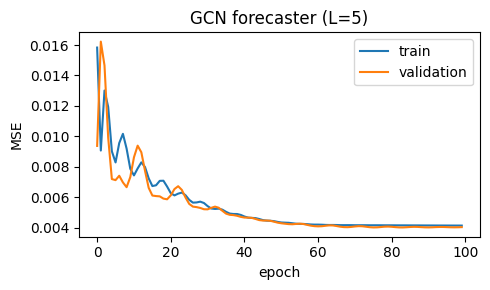

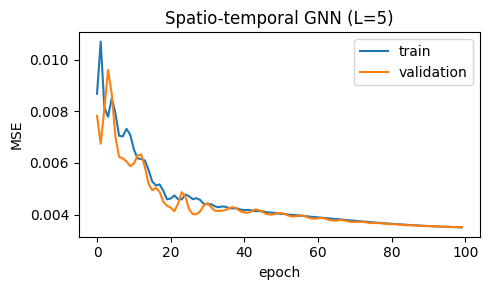

Model                   Params     Val MSE    Test MSE
------------------------------------------------------
GCN forecaster              97    0.004016    0.003693
Spatio-temporal GNN       1217    0.003516    0.003215


In [48]:
# C4: train and evaluate
# 1. GCNForecaster using L=5 windows,
# 2. SpatioTemporalGNN using L=5 windows.
# Plot training curves and report parameter counts, validation MSE, and test MSE.

graph_models = {}

set_seed(0)
gcn = GCNForecaster().to(DEVICE)
gcn_hist, _ = train_model(gcn, windows['train'], windows['val'], A_hat, epochs=100)
graph_models['GCN forecaster'] = (gcn, gcn_hist)

set_seed(0)
stgnn = SpatioTemporalGNN(L).to(DEVICE)
stgnn_hist, _ = train_model(stgnn, windows['train'], windows['val'], A_hat, epochs=100)
graph_models['Spatio-temporal GNN'] = (stgnn, stgnn_hist)

# training/validation loss curves
for name, (model, hist) in graph_models.items():
    plot_loss_curves(hist, title=f"{name} (L={L})")

# parameter counts + val/test MSE
graph_results = {}
header = f"{'Model':<22}{'Params':>8}{'Val MSE':>12}{'Test MSE':>12}"
print(header); print('-' * len(header))
for name, (model, hist) in graph_models.items():
    res = {s: evaluate_model(model, windows[s], A_hat) for s in ('val', 'test')}
    graph_results[name] = res
    print(f"{name:<22}{count_parameters(model):>8}{res['val']:>12.6f}{res['test']:>12.6f}")

## Part D: ablations and final comparison

Run the history-length and graph ablations, then collect the final tables for the report.


In [49]:
def run_stgnn(L, graph_matrix, epochs=100, seed=0):
    """Build windows for L, train a fresh SpatioTemporalGNN, return (model, history, {val,test} MSE)."""
    w = make_windows(X, L, train_end, val_end)
    set_seed(seed)
    model = SpatioTemporalGNN(L).to(DEVICE)
    history, _ = train_model(model, w['train'], w['val'], graph_matrix, epochs=epochs)
    res = {s: evaluate_model(model, w[s], graph_matrix) for s in ('val', 'test')}
    return model, history, res


In [50]:
# D1: history-length ablation for the SpatioTemporalGNN.
# Train with L in {1, 3, 5, 10}. Rebuild the windows for each L.

d1_results = {L_ab: run_stgnn(L_ab, A_hat)[2] for L_ab in (1, 3, 5, 10)}

header = f"{'L':>3}{'Val MSE':>12}{'Test MSE':>12}"
print(header); print('-' * len(header))
for L_ab, res in d1_results.items():
    print(f"{L_ab:>3}{res['val']:>12.6f}{res['test']:>12.6f}")

best_L = min(d1_results, key=lambda L_ab: d1_results[L_ab]['val'])
print(f"\nbest L (by val MSE): {best_L}")


100%|██████████| 100/100 [00:00<00:00, 520.46it/s]

  L     Val MSE    Test MSE
---------------------------
  1    0.003872    0.003679
  3    0.003515    0.003156
  5    0.003516    0.003215
 10    0.003700    0.003398

best L (by val MSE): 3


In [51]:
# TODO D2: graph ablation.
# Repeat the L=5 SpatioTemporalGNN experiment with graph_matrix = identity.

I = np.eye(A_hat.shape[0], dtype=np.float32)
_, _, nograph_res = run_stgnn(5, I)
print(f"STGNN L=5, no graph (I):  val {nograph_res['val']:.6f} | test {nograph_res['test']:.6f}")

# D2 table: GCN (C4) + STGNN A_hat rows (D1) + the no-graph row
print(f"\n{'Model':<22}{'L':>3}{'Graph':>7}{'Test MSE':>12}")
print('-' * 44)
print(f"{'GCN forecaster':<22}{1:>3}{'A_hat':>7}{graph_results['GCN forecaster']['test']:>12.6f}")
for L_ab in (1, 3, 5, 10):
    print(f"{'Spatio-temporal GNN':<22}{L_ab:>3}{'A_hat':>7}{d1_results[L_ab]['test']:>12.6f}")
print(f"{'Spatio-temporal GNN':<22}{5:>3}{'I':>7}{nograph_res['test']:>12.6f}")

100%|██████████| 100/100 [00:00<00:00, 532.51it/s]


STGNN L=5, no graph (I):  val 0.001238 | test 0.001251

Model                   L  Graph    Test MSE
--------------------------------------------
GCN forecaster          1  A_hat    0.003693
Spatio-temporal GNN     1  A_hat    0.003679
Spatio-temporal GNN     3  A_hat    0.003156
Spatio-temporal GNN     5  A_hat    0.003215
Spatio-temporal GNN    10  A_hat    0.003398
Spatio-temporal GNN     5      I    0.001251


In [52]:
# D3: collect final results in tables for the report.
# Include the baselines, GCNForecaster, best-L SpatioTemporalGNN, and no-graph ablation.

final_rows = [
    ("Persistence",                          baseline_results["Persistence"][1]),
    ("Temporal MLP, L=5",                    baseline_results["Temporal MLP"][1]),
    ("Linear diffusion",                     baseline_results["Linear diffusion"][1]),
    ("GCN forecaster",                       graph_results["GCN forecaster"]),
    (f"Spatio-temporal GNN, best L={best_L}", d1_results[best_L]),
    ("Spatio-temporal GNN, L=5, no graph",   nograph_res),
]

header = f"{'Model':<36}{'Val MSE':>12}{'Test MSE':>12}"
print(header); print('-' * len(header))
for name, res in final_rows:
    print(f"{name:<36}{res['val']:>12.6f}{res['test']:>12.6f}")

# --- comparisons that answer the three questions ---
best_name, best_res = min(final_rows, key=lambda r: r[1]['test'])
hist_short, hist_long = d1_results[1]['test'], d1_results[best_L]['test']      # history: L=1 vs best L
graph_off  = nograph_res['test']                                              # L=5, I
graph_on   = graph_results["Spatio-temporal GNN"]['test']                     # L=5, A_hat

print(f"\n1) Best on test : {best_name}  (test MSE {best_res['test']:.6f})")
print(f"2) History  : STGNN L=1 {hist_short:.6f}  ->  best L={best_L} {hist_long:.6f}")
print(f"3) Graph    : STGNN L=5  no-graph {graph_off:.6f}  ->  A_hat {graph_on:.6f}")


Model                                    Val MSE    Test MSE
------------------------------------------------------------
Persistence                             0.001280    0.001313
Temporal MLP, L=5                       0.001116    0.001139
Linear diffusion                        0.001193    0.001219
GCN forecaster                          0.004016    0.003693
Spatio-temporal GNN, best L=3           0.003515    0.003156
Spatio-temporal GNN, L=5, no graph      0.001238    0.001251

1) Best on test : Temporal MLP, L=5  (test MSE 0.001139)
2) History  : STGNN L=1 0.003679  ->  best L=3 0.003156
3) Graph    : STGNN L=5  no-graph 0.001251  ->  A_hat 0.003215


## D3: result-based conclusions

**1. Which model performs best on the test set?**

The Temporal MLP (L=5) wins with a test MSE of 0.001139. Linear diffusion (0.001219) and persistence (0.001313) come next. Every graph model does much worse, with the best one (STGNN at L=3) only reaching 0.003156. The MLP is also best on validation, so the result is stable.

**2. Did temporal history help beyond using only x_t?**

A little. Inside the STGNN, going from L=1 to L=3 drops test MSE from 0.003679 to 0.003156. The Temporal MLP with 5 steps (0.001139) also beats persistence, which only sees x_t (0.001313). The gain is small because the signal changes slowly in time, so x_t already predicts most of the next step.

**3. Did graph structure help beyond node level temporal modeling?**

No, it made things worse. At L=5 with the same temporal part, swapping A_hat for the identity drops test MSE from 0.003215 to 0.001251. The models apply A_hat twice and keep no direct copy of the original signal, so they smooth away the parts that matter most: the 0.35 x_t term and the forcing on a few nodes. A single graph step or a residual connection would likely be needed for the graph to help.
